In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

# Варіант 5 — Дніпро
city = "Дніпро"
mean_temp = 10.0
amplitude = 14
hum_base = 70

rows = []

for month in range(1, 13):
    temp = (
        mean_temp
        + amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
        + np.random.normal(0, 1.0)
    )

    humidity = hum_base + np.random.normal(0, 5.0)

    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1)
    })

heating = pd.DataFrame(rows)

heating

,місто,місяць,температура,вологість,опалювальні_дні,витрати_на_опалення
0,Дніпро,1,-3.5,69.3,30,357.8
1,Дніпро,2,-0.6,68.8,30,318.2
2,Дніпро,3,4.6,73.8,30,271.0
3,Дніпро,4,10.5,67.7,15,176.2
4,Дніпро,5,17.2,60.4,0,55.2
5,Дніпро,6,21.6,64.9,0,49.6
6,Дніпро,7,23.1,62.9,0,51.9
7,Дніпро,8,21.9,70.3,0,23.7
8,Дніпро,9,16.5,70.6,0,77.0
9,Дніпро,10,10.4,67.0,15,179.9


In [2]:
X = heating[
    ["температура", "вологість"]
]

X = sm.add_constant(X)

y = heating["витрати_на_опалення"]

model_2 = sm.OLS(y, X).fit()

print(model_2.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.976
Model:                             OLS   Adj. R-squared:                  0.970
Method:                  Least Squares   F-statistic:                     179.6
Date:                 Sat, 19 Sep 2026   Prob (F-statistic):           5.58e-08
Time:                         09:50:30   Log-Likelihood:                -52.453
No. Observations:                   12   AIC:                             110.9
Df Residuals:                        9   BIC:                             112.4
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         227.0031    116.564      1

In [3]:
print("R² =", model_2.rsquared)
print("Adjusted R² =", model_2.rsquared_adj)

print("\nКоефіцієнти:")
print(model_2.params)

print("\np-value:")
print(model_2.pvalues)

R² = 0.9755559405064166
Adjusted R² = 0.9701239272856202

Коефіцієнти:
const          227.003065
температура    -12.282897
вологість        1.148312
dtype: float64

p-value:
const          8.330766e-02
температура    1.288664e-07
вологість      4.936209e-01
dtype: float64


Побудовано модель множинної лінійної регресії:

витрати =
227.003
- 12.283 × температура
+ 1.148 × вологість.

R² ≈ 0.976.

Adjusted R² ≈ 0.970.

Отже, модель із температурою та вологістю пояснює
приблизно 97.6% варіації витрат на опалення в цьому
наборі даних.

Adjusted R² трохи нижчий, оскільки він враховує
кількість предикторів у моделі.

Коефіцієнт температури становить приблизно -12.283.

За незмінної вологості збільшення середньомісячної
температури на 1 °C пов'язане зі зменшенням очікуваних
витрат на опалення приблизно на 12.28 умовних одиниць.

Для температури:

p ≈ 1.29 × 10⁻⁷.

Оскільки p < 0.05, температура є статистично
значущим предиктором витрат на опалення за інших
рівних умов.

Коефіцієнт вологості становить приблизно +1.148.

За незмінної температури збільшення вологості на
1 процентний пункт пов'язане зі збільшенням очікуваних
витрат приблизно на 1.15 умовних одиниць.

Для вологості:

p ≈ 0.494.

Оскільки p > 0.05, при рівні значущості α = 0.05
немає достатніх підстав вважати вологість статистично
значущим предиктором після врахування температури.

Це не означає, що доведено відсутність будь-якого
впливу вологості. За цією невеликою вибіркою її
окремий ефект статистично не виявлено.

In [4]:
vif_data = pd.DataFrame()

vif_data["предиктор"] = [
    "температура",
    "вологість"
]

vif_data["VIF"] = [
    variance_inflation_factor(X.values, 1),
    variance_inflation_factor(X.values, 2)
]

vif_data

,предиктор,VIF
0,температура,1.55295
1,вологість,1.55295


VIF для температури ≈ 1.55.
VIF для вологості ≈ 1.55.

Обидва значення значно нижчі за практичний поріг 5.

Отже, серйозної мультиколінеарності між температурою
та вологістю в цій моделі немає.

Це логічно випливає з генерації даних. Температура
формується на основі сезонної косинусоїди, тоді як
вологість генерується окремо як базова вологість
плюс випадковий шум.

У формулі генерації вологість безпосередньо не
залежить від температури, тому жорсткого лінійного
зв'язку між цими двома предикторами немає.

In [5]:
X3 = heating[
    [
        "температура",
        "вологість",
        "опалювальні_дні"
    ]
]

X3 = sm.add_constant(X3)

model_3 = sm.OLS(y, X3).fit()

print(model_3.summary())

                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.992
Model:                             OLS   Adj. R-squared:                  0.988
Method:                  Least Squares   F-statistic:                     314.0
Date:                 Sat, 19 Sep 2026   Prob (F-statistic):           1.23e-08
Time:                         09:51:33   Log-Likelihood:                -46.060
No. Observations:                   12   AIC:                             100.1
Df Residuals:                        8   BIC:                             102.1
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             231.0697     7

In [6]:
comparison = pd.DataFrame({
    "Модель": [
        "2 предиктори",
        "3 предиктори"
    ],
    "R²": [
        model_2.rsquared,
        model_3.rsquared
    ],
    "Adjusted R²": [
        model_2.rsquared_adj,
        model_3.rsquared_adj
    ]
})

comparison

,Модель,R²,Adjusted R²
0,2 предиктори,0.975556,0.970124
1,3 предиктори,0.991579,0.988421


In [7]:
vif_3 = pd.DataFrame()

vif_3["предиктор"] = [
    "температура",
    "вологість",
    "опалювальні_дні"
]

vif_3["VIF"] = [
    variance_inflation_factor(X3.values, 1),
    variance_inflation_factor(X3.values, 2),
    variance_inflation_factor(X3.values, 3)
]

vif_3

,предиктор,VIF
0,температура,13.409621
1,вологість,1.898510
2,опалювальні_дні,15.617899


Після додавання предиктора "опалювальні_дні":

R² зріс приблизно з 0.976 до 0.992.

Adjusted R² також зріс:
з приблизно 0.970 до 0.988.

Отже, додавання третього предиктора покращило модель
настільки, що це покращення перевищило штраф adjusted R²
за додатковий ступінь свободи.

Проте VIF показує важливу проблему:

температура: VIF ≈ 13.41;
вологість: VIF ≈ 1.90;
опалювальні_дні: VIF ≈ 15.62.

Для температури та опалювальних днів VIF перевищує 10,
що свідчить про сильну мультиколінеарність.

Це логічно, оскільки кількість опалювальних днів
безпосередньо визначається температурою:
при температурі нижче 8 °C задається 30 днів,
від 8 до 12 °C — 15 днів, а вище 12 °C — 0.

Отже, трипредикторна модель має вищий adjusted R²,
але окремі коефіцієнти температури та опалювальних
днів потрібно інтерпретувати обережно через сильну
мультиколінеарність.

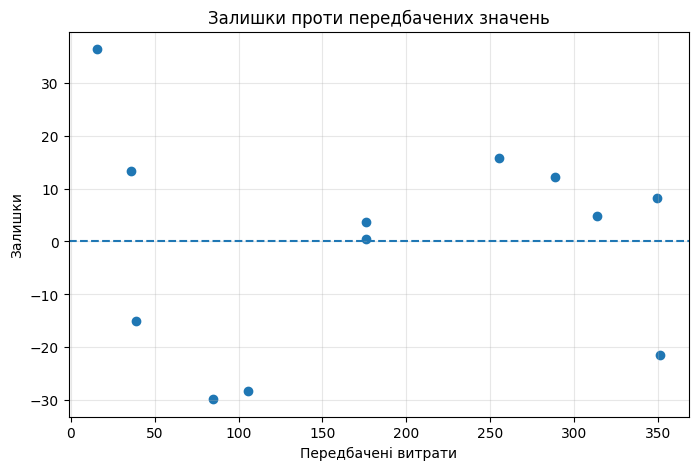

In [8]:
fitted = model_2.fittedvalues
residuals = model_2.resid

plt.figure(figsize=(8, 5))

plt.scatter(fitted, residuals)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Передбачені витрати")
plt.ylabel("Залишки")
plt.title("Залишки проти передбачених значень")

plt.grid(alpha=0.3)
plt.show()

In [9]:
print(
    "Кореляція залишків і прогнозів:",
    np.corrcoef(fitted, residuals)[0, 1]
)

Кореляція залишків і прогнозів: -3.0791724623941197e-15


На графіку залишки розташовані по обидва боки
від нульової лінії.

Явної лійкоподібної форми, тобто систематичного
збільшення або зменшення розкиду залишків разом
із передбаченими значеннями, не спостерігається.

Кореляція між залишками та передбаченими значеннями
практично дорівнює нулю.

Отже, за цим графіком немає явних ознак сильної
гетероскедастичності.

Водночас вибірка містить лише 12 спостережень,
тому візуальну діагностику слід трактувати обережно.

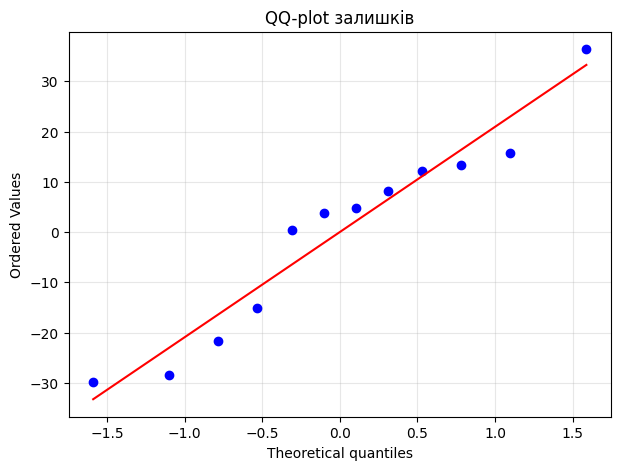

In [10]:
plt.figure(figsize=(7, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ-plot залишків")
plt.grid(alpha=0.3)

plt.show()

За критерієм Шапіро–Вілка отримано:

W ≈ 0.939;
p ≈ 0.483.

При α = 0.05 маємо p > 0.05, тому немає підстав
відхиляти нульову гіпотезу про нормальність залишків.

QQ-plot також не показує очевидного сильного
відхилення від нормального розподілу.

Отже, за цими даними припущення про нормальність
залишків не суперечить результатам діагностики.

Проте через малу кількість спостережень (n = 12)
цей висновок потрібно трактувати обережно.

In [11]:
X_simple = sm.add_constant(
    heating[["температура"]]
)

model_simple = sm.OLS(
    y,
    X_simple
).fit()

print("Проста модель:")
print("R² =", model_simple.rsquared)

print("\nМножинна модель:")
print("R² =", model_2.rsquared)
print("Adjusted R² =", model_2.rsquared_adj)

Проста модель:
R² = 0.9741732639828287

Множинна модель:
R² = 0.9755559405064166
Adjusted R² = 0.9701239272856202


Проста модель лише з температурою має:

R² ≈ 0.974.

Множинна модель з температурою та вологістю має:

R² ≈ 0.976;
adjusted R² ≈ 0.970.

Звичайний R² після додавання вологості трохи зріс,
що є очікуваним: додавання предиктора не може
зменшити звичайний R² у МНК-моделі.

Однак приріст дуже малий — приблизно з 0.974 до 0.976.

Крім того, adjusted R² множинної моделі становить
приблизно 0.970, тобто після штрафу за додатковий
предиктор результат не покращився.

Це узгоджується з результатом Завдання 2, де
коефіцієнт вологості мав p ≈ 0.494 і не був
статистично значущим.

Отже, для цього конкретного набору додавання вологості
до температури дає дуже мале покращення поясненої
дисперсії і не виправдовує ускладнення моделі за
adjusted R².

1. Чому sm.add_constant() є обов'язковим і що буде,
якщо його пропустити?

sm.add_constant() додає до матриці предикторів стовпець
константи, який потрібний для оцінювання вільного члена b0.

Завдяки цьому модель має вигляд:

y = b0 + b1*x1 + b2*x2 + ...

Якщо не додати константу, statsmodels.OLS не створить
її автоматично і модель буде примусово проходити через
початок координат.

Тобто при всіх x = 0 модель буде змушена прогнозувати
y = 0, навіть якщо це не відповідає даним.

Через це можуть суттєво змінитися коефіцієнти,
залишки та показники якості моделі.


2. Чим коефіцієнт множинної регресії відрізняється
від коефіцієнта простої регресії з тим самим
предиктором?

У простій регресії коефіцієнт показує загальний
лінійний зв'язок одного предиктора із залежною змінною.

У множинній регресії коефіцієнт показує зміну
очікуваного y при зміні конкретного предиктора
на одну одиницю за умови, що всі інші предиктори
залишаються незмінними.

Тому коефіцієнт температури у множинній моделі
інтерпретується як ефект температури за незмінної
вологості.

Через контроль інших змінних його значення може
відрізнятися від коефіцієнта простої регресії.


3. Чому звичайний R² не може зменшитися при
додаванні нового предиктора?

Метод найменших квадратів підбирає коефіцієнти так,
щоб мінімізувати суму квадратів залишків.

При додаванні нового предиктора модель отримує
додаткову можливість підлаштуватися під дані.
У найгіршому випадку вона може присвоїти новому
коефіцієнту значення 0 і фактично залишитися старою.

Тому сума квадратів залишків не може збільшитися,
а звичайний R² не може зменшитися.

Саме тому R² може трохи збільшуватися навіть після
додавання майже непотрібного предиктора.

Adjusted R² враховує кількість предикторів і штрафує
модель за зайве ускладнення, тому краще підходить
для порівняння моделей із різною кількістю змінних.


4. Що означає VIF ≈ 1 та VIF > 10?

VIF близько 1 означає, що предиктор практично не
пояснюється іншими предикторами моделі і серйозної
мультиколінеарності немає.

VIF понад 10 зазвичай вказує на сильну
мультиколінеарність.

У нашій моделі з трьома предикторами температура
має VIF ≈ 13.41, а опалювальні дні ≈ 15.62.

Причина полягає в тому, що опалювальні дні
безпосередньо визначаються температурою.

На практиці при високому VIF потрібно перевірити,
чи справді необхідно залишати обидва сильно пов'язані
предиктори. Можна видалити один із них, змінити
постановку моделі або використати інші методи,
якщо обидві змінні теоретично необхідні.